In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import statsmodels.api as sm

df = pd.read_csv("election2000.csv")
y = df["Bush"]
X = df[["UnE","Pop","Male","Male18","Pop65","NonMet","Pov","NuHouse","Inc50","Inc75","Inc100"]]

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   Bush   R-squared (uncentered):                   0.987
Model:                            OLS   Adj. R-squared (uncentered):              0.984
Method:                 Least Squares   F-statistic:                              285.0
Date:                Sun, 08 Feb 2026   Prob (F-statistic):                    2.32e-34
Time:                        14:20:33   Log-Likelihood:                         -161.03
No. Observations:                  51   AIC:                                      344.1
Df Residuals:                      40   BIC:                                      365.3
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [3]:
alpha = 0.05
pvals = model.pvalues
significant = pvals[pvals < alpha]

print(significant)

Pop65     0.003016
NonMet    0.000531
dtype: float64


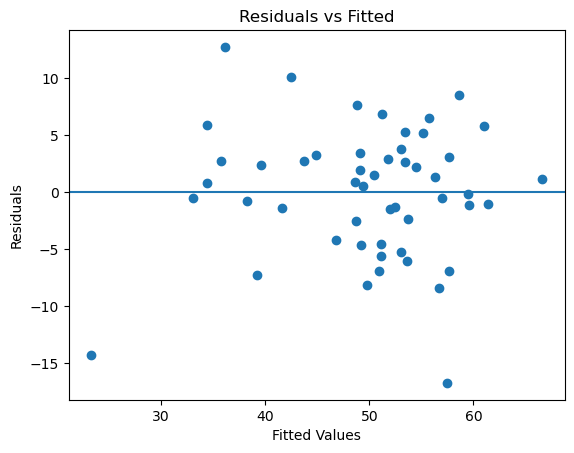

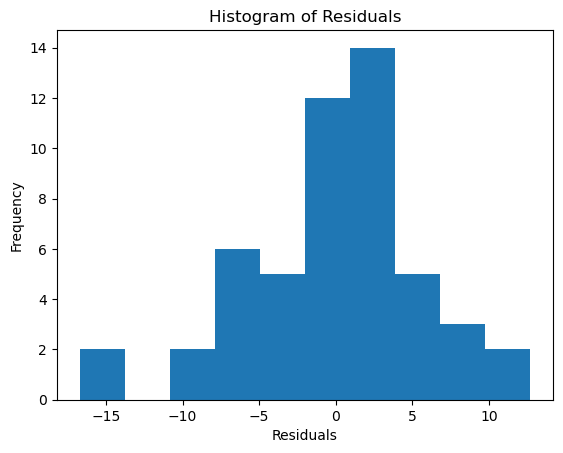

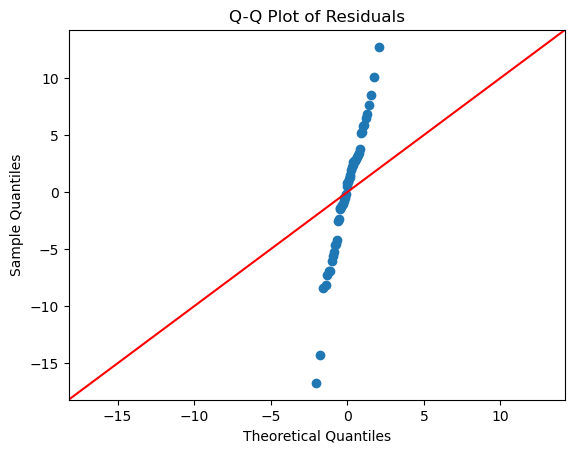

In [4]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

plt.figure()
plt.hist(residuals, bins=10)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

In [5]:
resid_std = (residuals - np.mean(residuals)) / np.std(residuals, ddof=1)

ks_stat, ks_p = stats.kstest(resid_std, "norm")

sw_stat, sw_p = stats.shapiro(residuals)

print(f"Kolmogorov–Smirnov p-value: {ks_p:.4f}")
print(f"Shapiro–Wilk p-value: {sw_p:.4f}")

Kolmogorov–Smirnov p-value: 0.6292
Shapiro–Wilk p-value: 0.3860


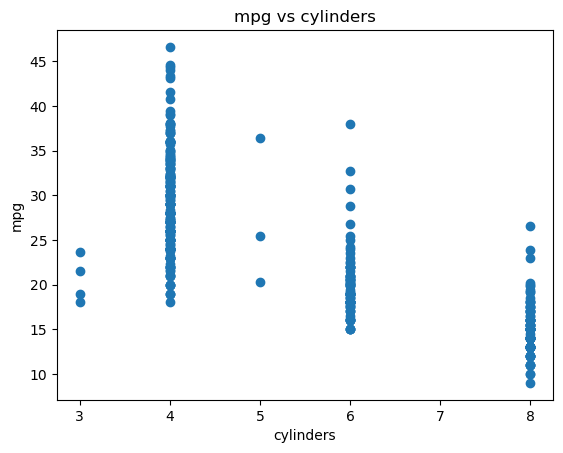

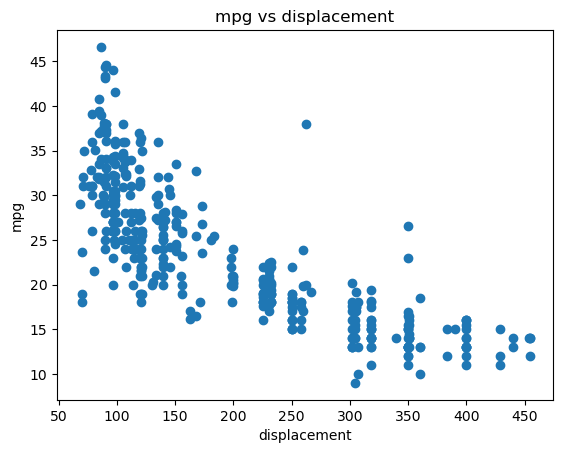

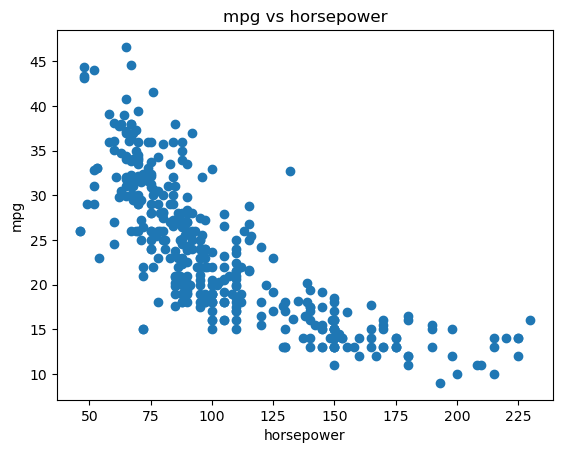

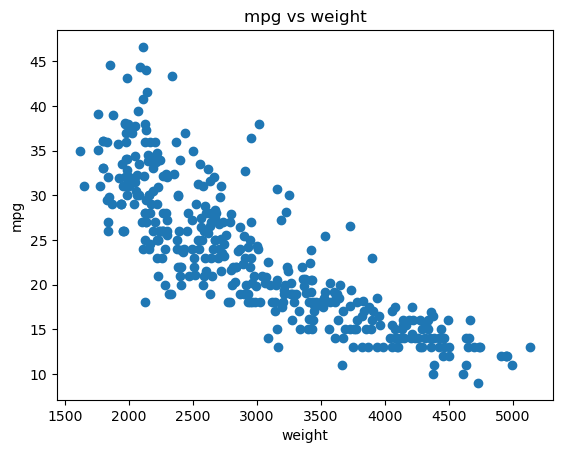

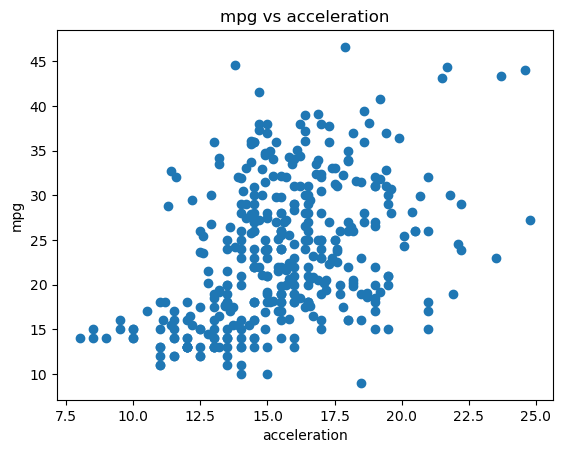

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Auto.csv")
df = df[["mpg","cylinders","displacement","horsepower","weight","acceleration"]].dropna()

for var in df.columns[1:]:
    plt.figure()
    plt.scatter(df[var], df["mpg"])
    plt.xlabel(var)
    plt.ylabel("mpg")
    plt.title(f"mpg vs {var}")
    plt.show()

In [6]:
if ks_p > alpha and sw_p > alpha:
    print("\nConclusion: Residuals satisfy the normality assumption.")
else:
    print("\nConclusion: Residuals violate the normality assumption.")
    


Conclusion: Residuals satisfy the normality assumption.


In [8]:
import statsmodels.api as sm

X = df[["cylinders","displacement","horsepower","weight","acceleration"]]
X = sm.add_constant(X)
y = df["mpg"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     186.9
Date:                Sun, 08 Feb 2026   Prob (F-statistic):          9.82e-101
Time:                        15:53:41   Log-Likelihood:                -1120.1
No. Observations:                 392   AIC:                             2252.
Df Residuals:                     386   BIC:                             2276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           46.2643      2.669     17.331   

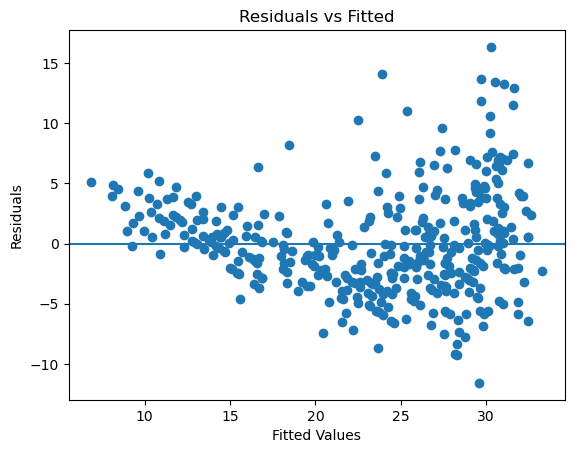

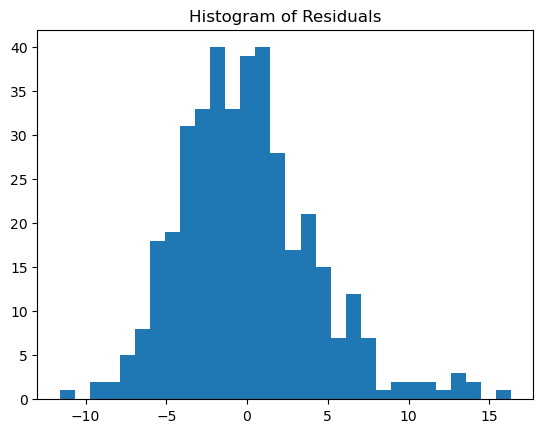

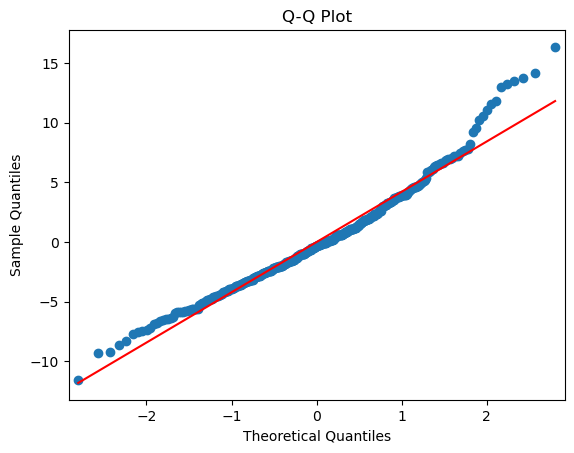

In [9]:
from scipy import stats

resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Histogram
plt.figure()
plt.hist(resid, bins=30)
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="s")
plt.title("Q-Q Plot")
plt.show()

In [10]:
ks_stat, ks_p = stats.kstest(
    (resid - np.mean(resid)) / np.std(resid),
    "norm"
)

sw_stat, sw_p = stats.shapiro(resid)

ks_p, sw_p


(0.043077103039786846, 6.723593408536014e-07)